# Customer Segmentation using PCA and t-SNE

### 1. Import Libraries
We import standard libraries for data analysis, preprocessing, dimensionality reduction, and plotting.

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

### 2. Load the Dataset
We load the `Mall_Customers.csv` dataset and inspect the first few rows to understand its structure.

In [2]:
dataset = "../../Datasets/Mall_Customers.csv"

df = pd.read_csv(dataset)

df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


### 3. Dataset Info
We check the data types, non-null counts, and memory usage using `df.info()`.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


### 4. Statistical Summary
We generate descriptive statistics for numerical columns to understand the mean, standard deviation, and quartiles.

In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### 5. Check for Missing Values
We check for any null or missing values to ensure the dataset is clean and doesn't require imputation.

In [5]:
print(df.isnull().sum())
print()
print(df.isna().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


### 6. Check for Duplicate Rows
We verify if there are any duplicate customer records in the dataset.

In [6]:
print(df.duplicated().sum())

0


### 7. Data Preprocessing
We drop the `CustomerID` column (which has no predictive power) and map categorical `Gender` to numerical values (`Male` -> 0, `Female` -> 1).

In [10]:
df_clean = df.drop(columns=['CustomerID'])
df_clean['Gender'] = df_clean['Gender'].map({'Male': 0, 'Female': 1})

### 8. Exploratory Data Analysis (EDA)
We generate pairwise relationship plots, feature distributions, and a correlation heatmap to understand our data before reduction.

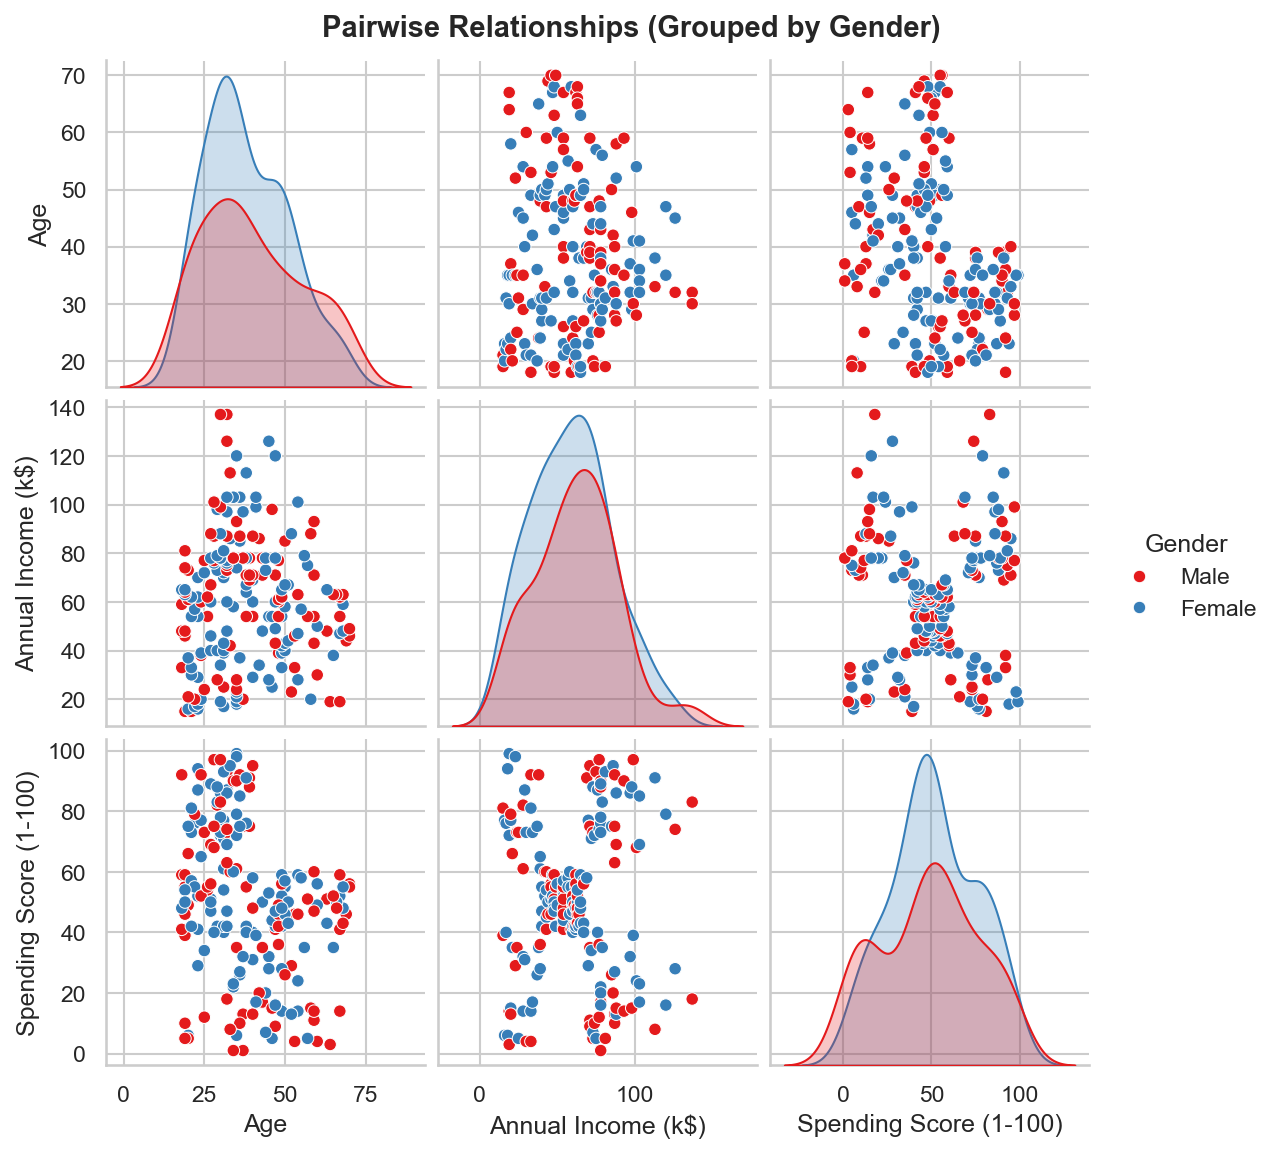

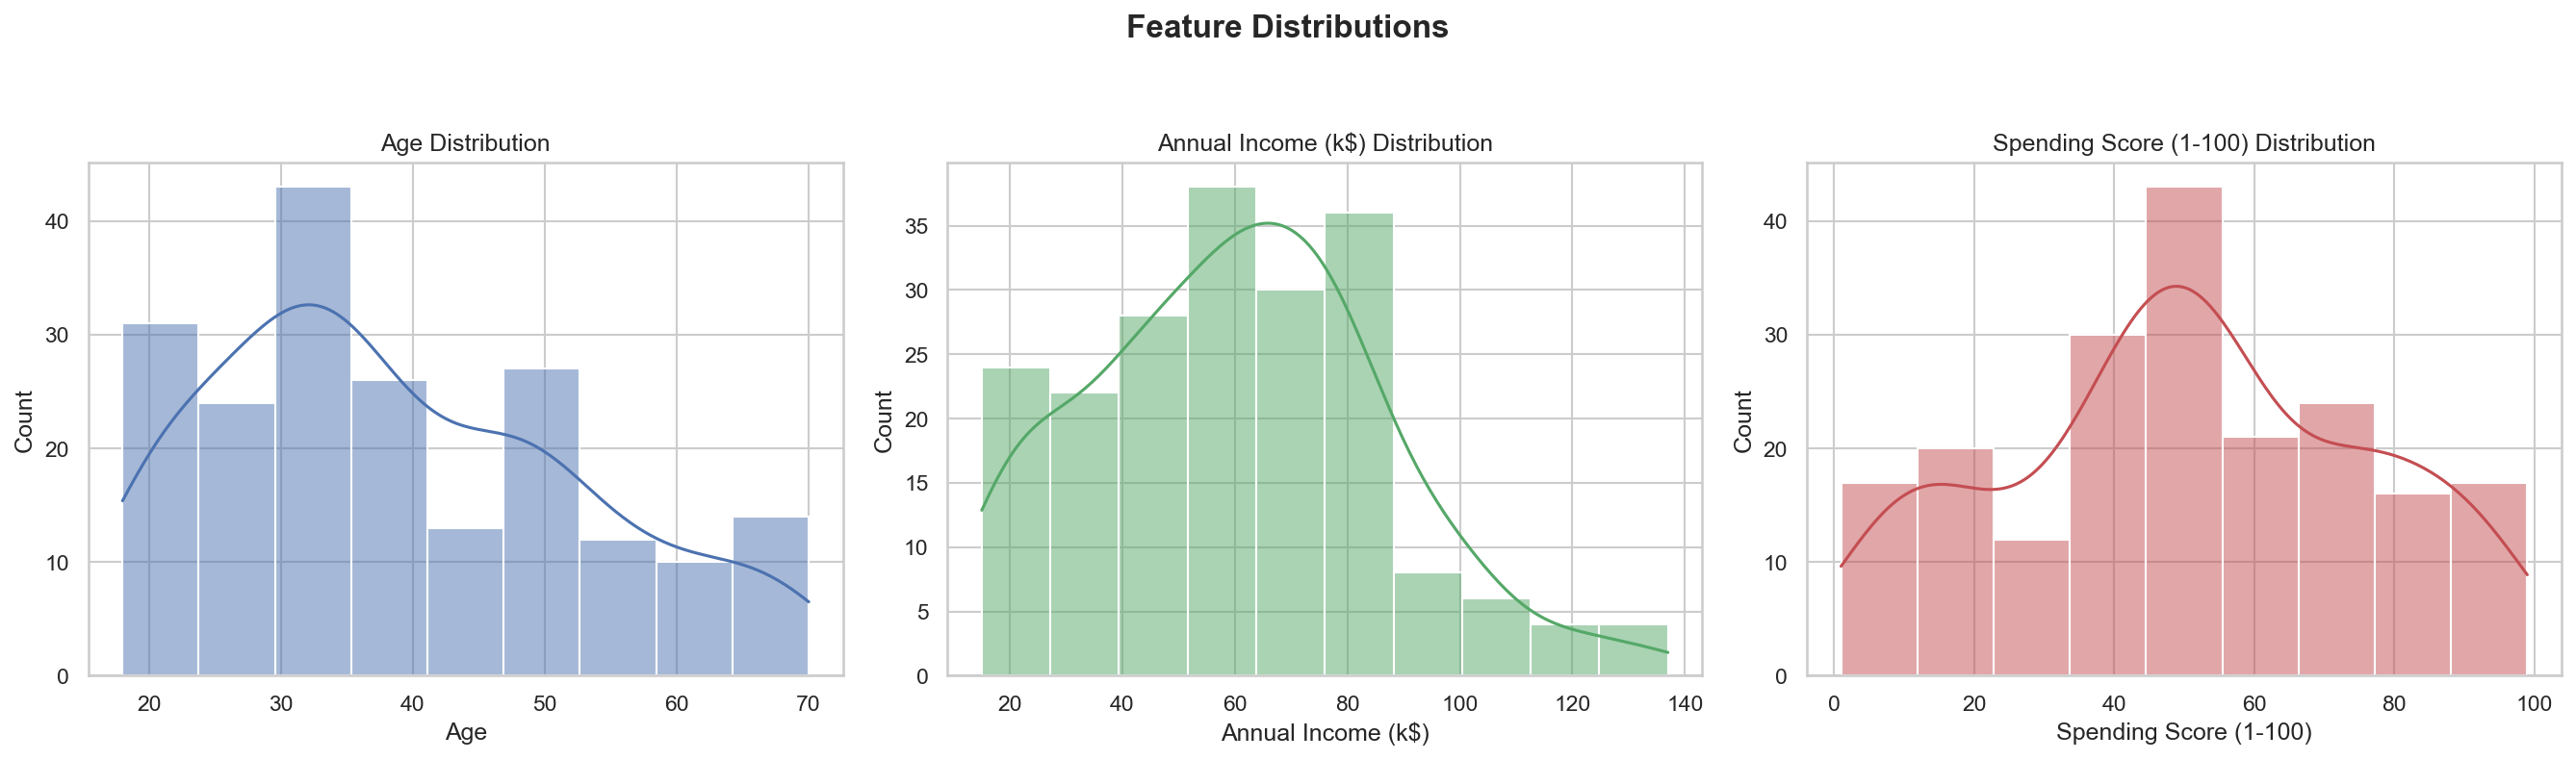

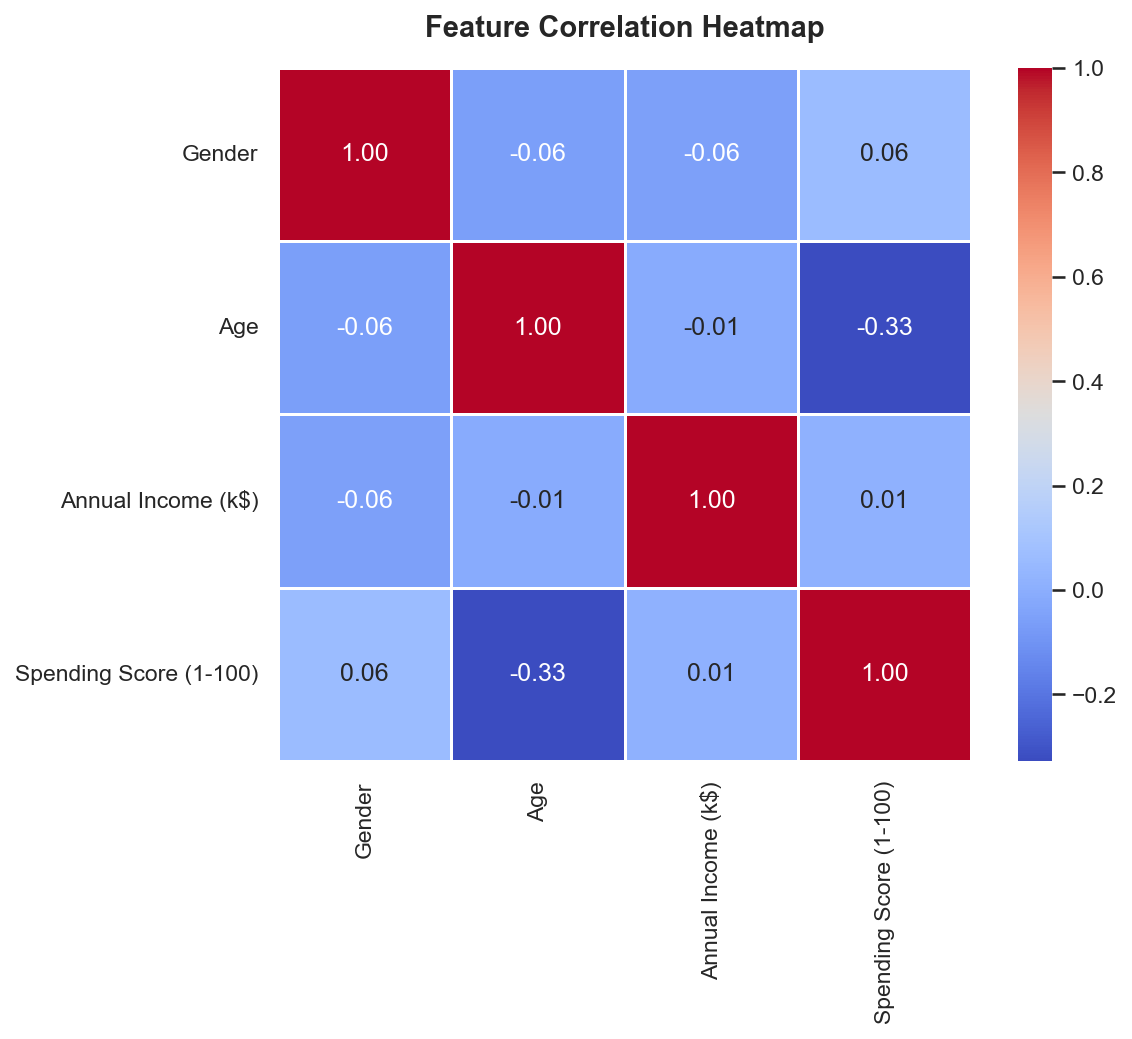

In [17]:
# =====================================================================
# VISUALIZATION 1: Pairwise Relationships (Pairplot)
# =====================================================================

# This shows how every feature combination behaves, grouped by Gender
pair_plot = sns.pairplot(df.drop(columns=['CustomerID']), hue='Gender', palette='Set1', height=2.5)
pair_plot.fig.suptitle("Pairwise Relationships (Grouped by Gender)", y=1.02, fontsize=14, fontweight='bold')
plt.show()

# =====================================================================
# VISUALIZATION 2: Feature Distributions & Outliers
# =====================================================================

# This helps check if columns are skewed or contain extreme outliers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Feature Distributions", fontsize=16, fontweight='bold', y=1.05)
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
colors = ['#4C72B0', '#55A868', '#C44E52']
for i, col in enumerate(features):
    sns.histplot(df_clean[col], kde=True, color=colors[i], ax=axes[i])
    axes[i].set_title(f'{col} Distribution', fontsize=12)
    axes[i].set_xlabel(col)
plt.tight_layout()
plt.show()

# =====================================================================
# VISUALIZATION 3: Feature Correlation Heatmap
# =====================================================================

# This helps check if there is any multicollinearity (redundancy)
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.show()

### 9. Feature Scaling
Dimensionality reduction models are sensitive to differences in feature scales. We use `StandardScaler` to transform our columns to have a mean of 0 and a variance of 1.

In [12]:
scaler = StandardScaler()

df_scaled = scaler.fit_transform(df_clean)

### 10. Principal Component Analysis (PCA)
We apply standard PCA to find linear projections that maximize the variance and reduce the dataset from 4 dimensions down to 2 dimensions.

In [14]:
pca = PCA(n_components=2).fit_transform(df_scaled)

### 11. t-SNE Projection
We apply t-SNE (t-Distributed Stochastic Neighbor Embedding) to find a non-linear 2D projection that preserves local similarities.

In [16]:
tsne = TSNE(
    n_components=2, 
    perplexity=30, 
    random_state=42
).fit_transform(df_scaled)

### 12. Visualization: PCA vs t-SNE
We plot both projections side-by-side, color-coding the points by Spending Score, to compare how each algorithm separates the customer segments.

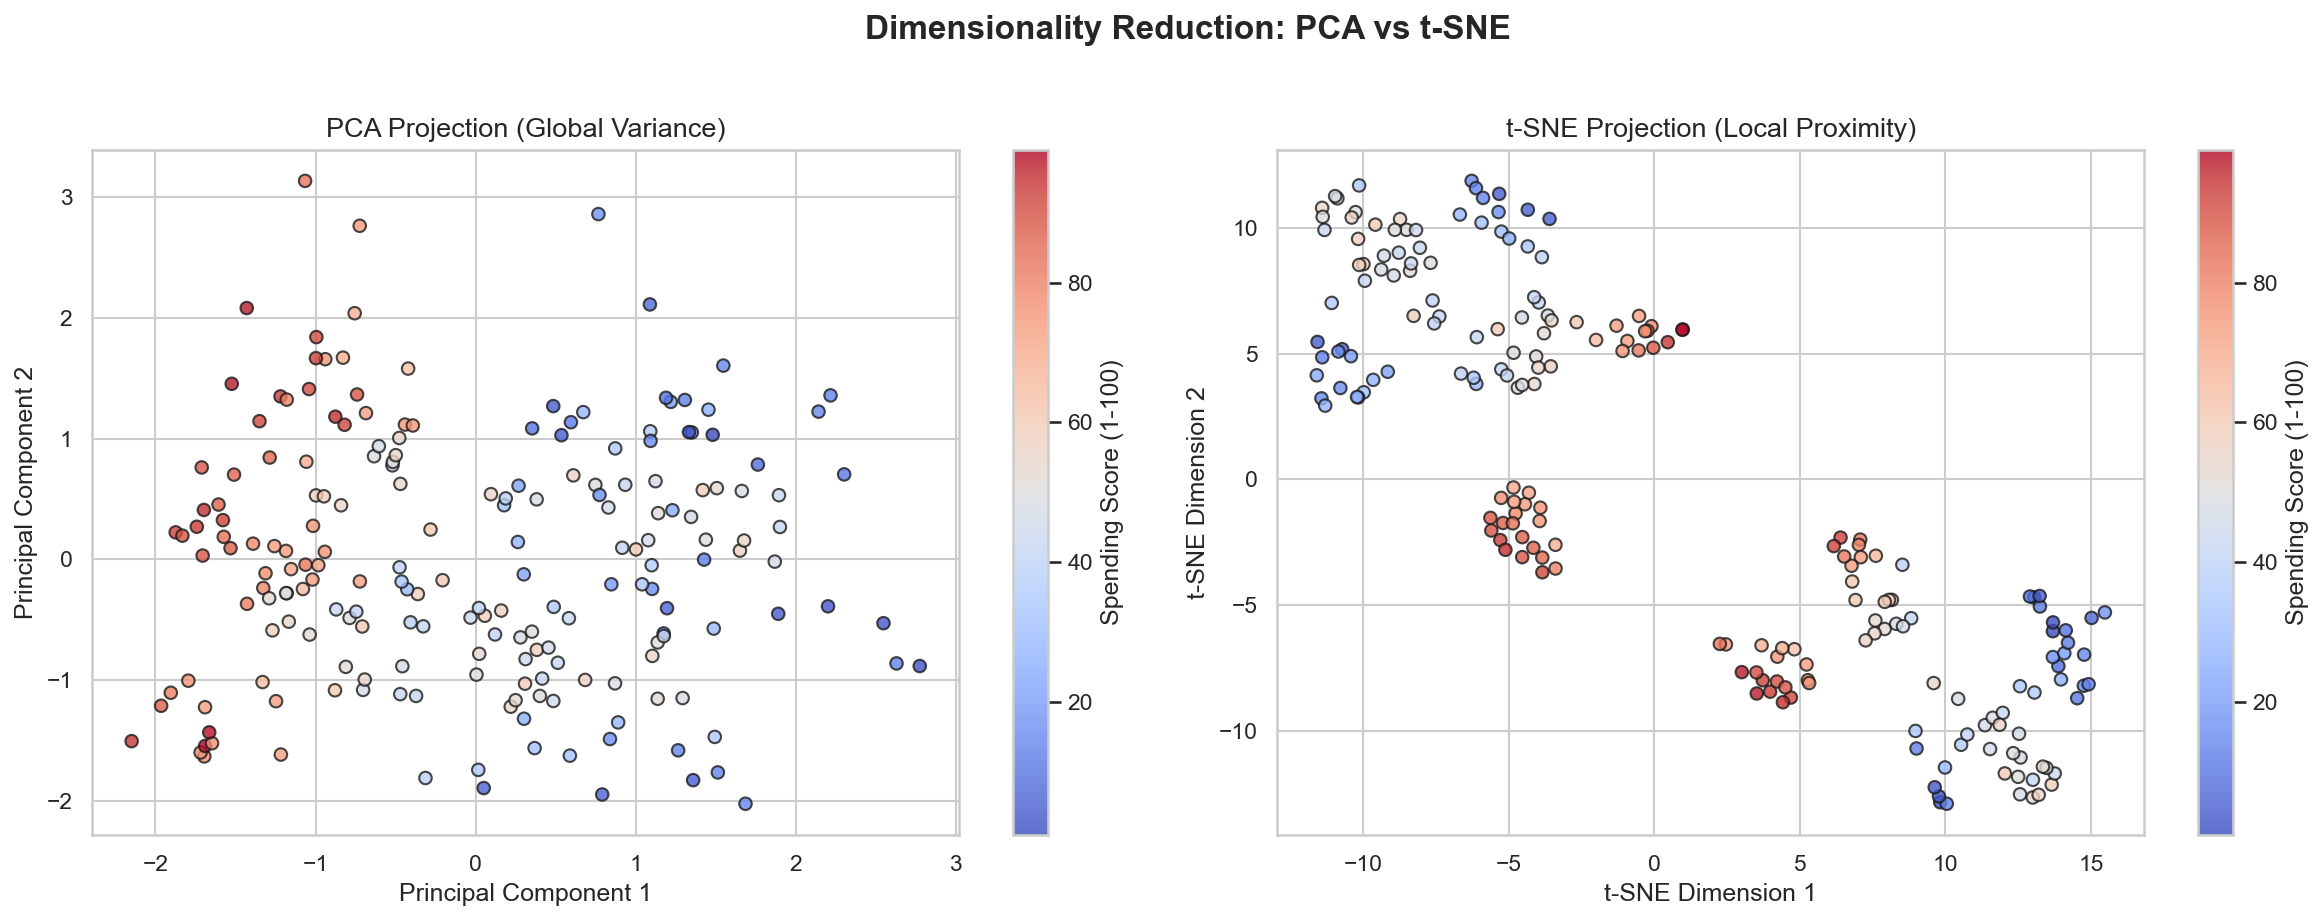

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Dimensionality Reduction: PCA vs t-SNE", fontsize=16, fontweight='bold', y=1.02)

# Scatter plot for PCA
scatter_pca = axes[0].scatter(
    pca[:, 0], 
    pca[:, 1], 
    c=df['Spending Score (1-100)'], 
    cmap='coolwarm', 
    edgecolor='k', 
    alpha=0.8
)
axes[0].set_title('PCA Projection (Global Variance)', fontsize=13)
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
fig.colorbar(scatter_pca, ax=axes[0], label='Spending Score (1-100)')

# Scatter plot for t-SNE
scatter_tsne = axes[1].scatter(
    tsne[:, 0], 
    tsne[:, 1], 
    c=df['Spending Score (1-100)'], 
    cmap='coolwarm', 
    edgecolor='k', 
    alpha=0.8
)
axes[1].set_title('t-SNE Projection (Local Proximity)', fontsize=13)
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
fig.colorbar(scatter_tsne, ax=axes[1], label='Spending Score (1-100)')
plt.tight_layout()
plt.show()

### 13. Results Analysis & Interpretation

#### A. What the t-SNE Visualization Suggests (5 Customer Segments)
When you run t-SNE, you will see the customers group into 5 distinct, isolated clusters (islands) in the 2D space. These 5 clusters represent the 5 natural market segments in your customer base:
- **Cluster 1 (High Income, Low Spending)**: The "Careful" group. They earn a lot but don't spend much at the mall.
- **Cluster 2 (High Income, High Spending)**: The "Target / Spendthrifts" group. They earn a lot and spend a lot. These are your most valuable customers.
- **Cluster 3 (Average Income, Average Spending)**: The "Standard / Sensible" group. They sit right in the middle of both axes.
- **Cluster 4 (Low Income, High Spending)**: The "Careless" group. They don't earn much but spend heavily.
- **Cluster 5 (Low Income, Low Spending)**: The "Thrifty" group. They earn little and spend little.

**Why t-SNE succeeded**: By focusing on preserving local neighbors, t-SNE successfully separates these 5 groups into visually distinct clumps on your plot.

#### B. What the PCA Visualization Suggests (Linear Transitions)
When you look at the PCA projection:
- The 5 customer groups will overlap heavily compared to the t-SNE plot. You won't see 5 clean, isolated islands; instead, you'll see a continuous cloud of points.
- **Why PCA looks like this**: PCA is a linear projection. It rotates the 4D space to show the view that has the widest spread (maximum variance). Because it is linear, it cannot bend or wrap the space to isolate clusters that aren't linearly separated. It shows you the global transition of the data but is less helpful for segmenting the clusters visually.

#### Summary
- **PCA** shows that the data is continuous and transitions smoothly, capturing the main axes of variance (principally driven by Annual Income and Spending Score).
- **t-SNE** suggests that your market naturally splits into 5 very clear customer personas that you can target individually with tailored marketing campaigns.